# Thyroid Model Notebook — Ontology-Matched ML Pipeline

This notebook builds a Thyroid Disease Support Model using the uploaded `thyroidDF.csv`.

The frontend form has:

- TSH (mIU/L)
- T3 (ng/dL)
- T4 (ug/dL)

So this notebook makes the model features match the UI exactly:

- `TSH`
- `T3_ng_dL`
- `T4_ug_dL`

We train and compare at least 4 models, then save the best one for FastAPI / Streamlit integration.

In [1]:
# If needed, install:
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

## 1. Load the dataset

In [2]:
DATA_PATH = "thyroidDF.csv"   # keep the CSV in the same folder as this notebook

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (9172, 31)


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
0,29,F,f,f,f,f,f,f,f,t,...,NaN,f,NaN,f,NaN,f,NaN,other,-,840801013
1,29,F,f,f,f,f,f,f,f,f,...,128.0,f,NaN,f,NaN,f,NaN,other,-,840801014
2,41,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,11.0,other,-,840801042
3,36,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,26.0,other,-,840803046
4,32,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,36.0,other,S,840803047


## 2. Select only the columns that match the UI

In [3]:
# Dataset columns:
# TSH is already in mIU/L.
# T3 in this dataset is commonly stored around 1-3, which is compatible with nmol/L.
# TT4 is commonly stored around 60-160, which is compatible with nmol/L.
# The frontend uses T3 ng/dL and T4 ug/dL, so we convert them.

needed_cols = ["TSH", "T3", "TT4"]
thyroid = df[needed_cols].copy()

print(thyroid.isna().sum())
thyroid.head()

TSH     842
T3     2604
TT4     442
dtype: int64


,TSH,T3,TT4
0,0.3,NaN,NaN
1,1.6,1.9,128.0
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN


## 3. Clean missing and impossible values

In [4]:
thyroid = thyroid.dropna(subset=["TSH", "T3", "TT4"]).copy()

# Remove impossible / extreme entry errors, but keep medically abnormal values.
thyroid = thyroid[
    (thyroid["TSH"] > 0) &
    (thyroid["T3"] > 0) &
    (thyroid["TT4"] > 0)
].copy()

print("After cleaning:", thyroid.shape)
thyroid.describe()

After cleaning: (6325, 3)


,TSH,T3,TT4
count,6325.000000,6325.000000,6325.000000
mean,5.153709,1.959050,107.798824
std,24.393017,0.880244,37.342110
min,0.005000,0.050000,2.000000
25%,0.400000,1.500000,87.000000
50%,1.300000,1.900000,104.000000
75%,2.700000,2.300000,124.000000
max,530.000000,18.000000,450.000000


## 4. Convert units to match the frontend

The UI expects:

| UI Input | Dataset column | Conversion |
|---|---|---|
| TSH mIU/L | TSH | no conversion |
| T3 ng/dL | T3 | `T3 * 65.1` |
| T4 ug/dL | TT4 | `TT4 / 12.87` |

This makes the model receive the same units the user enters in the website.

In [5]:
thyroid["T3_ng_dL"] = thyroid["T3"] * 65.1
thyroid["T4_ug_dL"] = thyroid["TT4"] / 12.87

model_df = thyroid[["TSH", "T3_ng_dL", "T4_ug_dL"]].copy()
model_df.describe()

,TSH,T3_ng_dL,T4_ug_dL
count,6325.000000,6325.000000,6325.000000
mean,5.153709,127.534142,8.375977
std,24.393017,57.303915,2.901485
min,0.005000,3.255000,0.155400
25%,0.400000,97.650000,6.759907
50%,1.300000,123.690000,8.080808
75%,2.700000,149.730000,9.634810
max,530.000000,1171.800000,34.965035


## 5. Build medical target labels

Because the frontend only uses TSH, T3, and T4, we create ontology-compatible labels using medical threshold rules.

Classes:

- `Normal`
- `Hypothyroidism`
- `Hyperthyroidism`

Rules used:

- Hypothyroidism pattern: high TSH with low T4
- Hyperthyroidism pattern: low TSH with high T3 or T4
- Otherwise: Normal

These labels match the ontology findings:

- `High_TSH`
- `Low_TSH`
- `Low_T4`
- `High_T3`
- `High_T4`

In [6]:
def thyroid_label(row):
    tsh = row["TSH"]
    t3 = row["T3_ng_dL"]
    t4 = row["T4_ug_dL"]

    # Reference ranges used for educational decision-support:
    # TSH: 0.4 - 4.0 mIU/L
    # T3: 80 - 180 ng/dL
    # T4: 5 - 12 ug/dL

    if tsh > 4.0 and t4 < 5.0:
        return "Hypothyroidism"
    elif tsh < 0.4 and (t4 > 12.0 or t3 > 180.0):
        return "Hyperthyroidism"
    else:
        return "Normal"

model_df["target"] = model_df.apply(thyroid_label, axis=1)

model_df["target"].value_counts()

target
Normal             5587
Hyperthyroidism     476
Hypothyroidism      262
Name: count, dtype: int64

## 6. Quick EDA

target
Normal             88.332016
Hyperthyroidism     7.525692
Hypothyroidism      4.142292
Name: proportion, dtype: float64


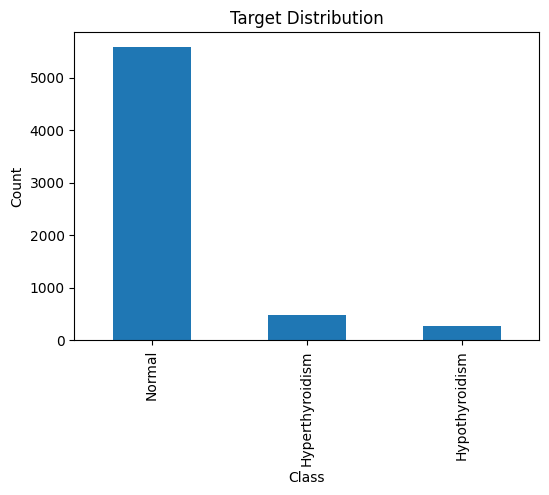

In [7]:
print(model_df["target"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
model_df["target"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

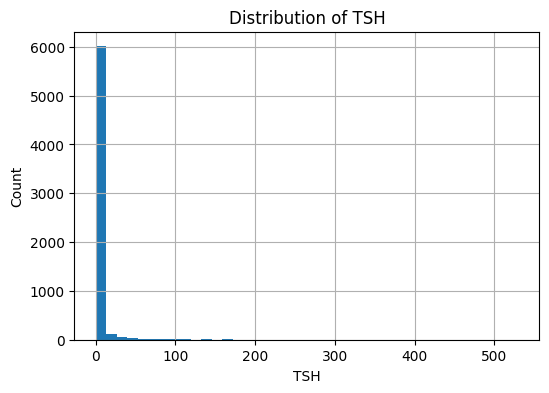

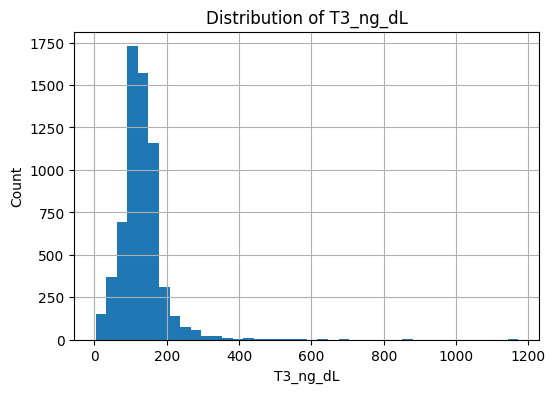

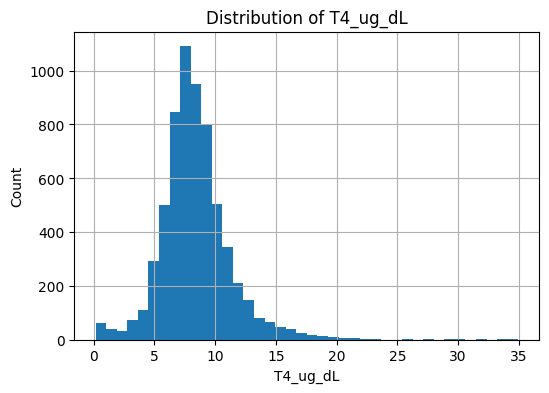

In [8]:
for col in ["TSH", "T3_ng_dL", "T4_ug_dL"]:
    plt.figure(figsize=(6,4))
    model_df[col].hist(bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 7. Prepare X and y

In [9]:
X = model_df[["TSH", "T3_ng_dL", "T4_ug_dL"]]
y = model_df["target"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", list(label_encoder.classes_))

Classes: ['Hyperthyroidism', 'Hypothyroidism', 'Normal']


## 8. Train/Test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (5060, 3)
Test: (1265, 3)


## 9. Train at least 4 models and compare

In [11]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
    ])
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision_macro": precision_score(y_test, preds, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_test, preds, average="macro", zero_division=0),
        "F1_macro": f1_score(y_test, preds, average="macro", zero_division=0),
        "F1_weighted": f1_score(y_test, preds, average="weighted", zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values(by="F1_macro", ascending=False)
results_df

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted
1,Decision Tree,0.999209,0.999702,0.993590,0.996615,0.999206
2,Random Forest,0.999209,0.999702,0.993590,0.996615,0.999206
3,Gradient Boosting,0.999209,0.999702,0.993590,0.996615,0.999206
0,Logistic Regression,0.895652,0.685747,0.934959,0.768939,0.907533
4,SVM,0.885375,0.673434,0.956768,0.760476,0.900381


## 10. Select the best model

For medical classification, macro F1 and recall are important because the minority disease classes matter.

In [12]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Decision Tree


## 11. Detailed evaluation for the best model

                 precision    recall  f1-score   support

Hyperthyroidism       1.00      1.00      1.00        95
 Hypothyroidism       1.00      0.98      0.99        52
         Normal       1.00      1.00      1.00      1118

       accuracy                           1.00      1265
      macro avg       1.00      0.99      1.00      1265
   weighted avg       1.00      1.00      1.00      1265



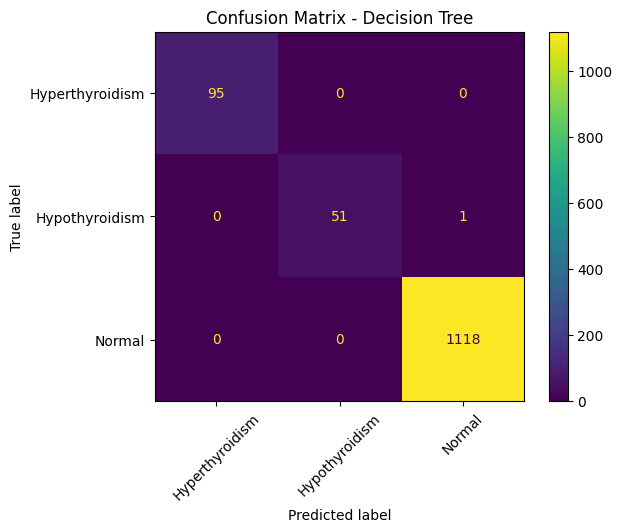

In [13]:
best_preds = best_model.predict(X_test)

print(classification_report(
    y_test,
    best_preds,
    target_names=label_encoder.classes_,
    zero_division=0
))

cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation=45)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## 12. Feature importance

,Feature,Importance
2,T4_ug_dL,0.527244
0,TSH,0.368659
1,T3_ng_dL,0.104097


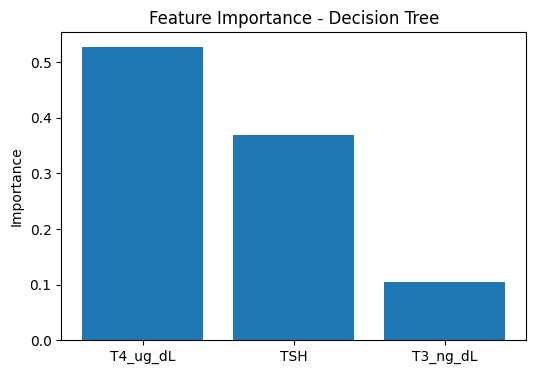

In [14]:
feature_names = ["TSH", "T3_ng_dL", "T4_ug_dL"]

importance_model = best_model
if isinstance(best_model, Pipeline):
    importance_model = best_model.named_steps["model"]

if hasattr(importance_model, "feature_importances_"):
    importances = importance_model.feature_importances_
    fi = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    display(fi)

    plt.figure(figsize=(6,4))
    plt.bar(fi["Feature"], fi["Importance"])
    plt.title(f"Feature Importance - {best_model_name}")
    plt.ylabel("Importance")
    plt.show()

elif hasattr(importance_model, "coef_"):
    coefs = np.abs(importance_model.coef_).mean(axis=0)
    fi = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient_Abs_Mean": coefs
    }).sort_values(by="Coefficient_Abs_Mean", ascending=False)

    display(fi)

    plt.figure(figsize=(6,4))
    plt.bar(fi["Feature"], fi["Coefficient_Abs_Mean"])
    plt.title(f"Feature Coefficients - {best_model_name}")
    plt.ylabel("Absolute coefficient mean")
    plt.show()

else:
    print("This model does not expose simple feature importance.")

## 13. Ontology findings function

In [15]:
def thyroid_ontology_findings(tsh, t3_ng_dl, t4_ug_dl):
    findings = []

    if tsh < 0.4:
        findings.append("Low_TSH")
    elif tsh > 4.0:
        findings.append("High_TSH")
    else:
        findings.append("Normal_TSH")

    if t3_ng_dl < 80:
        findings.append("Low_T3")
    elif t3_ng_dl > 180:
        findings.append("High_T3")
    else:
        findings.append("Normal_T3")

    if t4_ug_dl < 5:
        findings.append("Low_T4")
    elif t4_ug_dl > 12:
        findings.append("High_T4")
    else:
        findings.append("Normal_T4")

    return findings


def recommend_thyroid_tests(prediction_label, findings):
    recommendations = {
        "Hypothyroidism": [
            "Repeat TSH",
            "Free T4",
            "Anti-TPO antibodies",
            "Endocrinology consultation"
        ],
        "Hyperthyroidism": [
            "Repeat TSH",
            "Free T4",
            "Free T3",
            "TSH receptor antibodies",
            "Endocrinology consultation"
        ],
        "Normal": [
            "Clinical follow-up if symptoms persist"
        ]
    }

    return recommendations.get(prediction_label, ["Clinical follow-up"])

## 14. Prediction function for FastAPI / Streamlit

In [16]:
def predict_thyroid(tsh, t3_ng_dl, t4_ug_dl):
    input_df = pd.DataFrame([{
        "TSH": tsh,
        "T3_ng_dL": t3_ng_dl,
        "T4_ug_dL": t4_ug_dl
    }])

    pred_encoded = best_model.predict(input_df)[0]
    pred_label = label_encoder.inverse_transform([pred_encoded])[0]

    probabilities = None
    if hasattr(best_model, "predict_proba"):
        probas = best_model.predict_proba(input_df)[0]
        probabilities = {
            label: round(float(prob), 4)
            for label, prob in zip(label_encoder.classes_, probas)
        }

    findings = thyroid_ontology_findings(tsh, t3_ng_dl, t4_ug_dl)

    return {
        "prediction": pred_label,
        "probabilities": probabilities,
        "ontology_findings": findings,
        "recommended_tests": recommend_thyroid_tests(pred_label, findings)
    }


# Example from frontend:
predict_thyroid(tsh=0.1, t3_ng_dl=210, t4_ug_dl=14)

{'prediction': 'Hyperthyroidism',
 'probabilities': {'Hyperthyroidism': 1.0,
  'Hypothyroidism': 0.0,
  'Normal': 0.0},
 'ontology_findings': ['Low_TSH', 'High_T3', 'High_T4'],
 'recommended_tests': ['Repeat TSH',
  'Free T4',
  'Free T3',
  'TSH receptor antibodies',
  'Endocrinology consultation']}

## 15. Save artifacts

In [17]:
artifact = {
    "best_model_name": best_model_name,
    "features": ["TSH", "T3_ng_dL", "T4_ug_dL"],
    "classes": list(label_encoder.classes_),
    "unit_notes": {
        "TSH": "mIU/L",
        "T3_ng_dL": "ng/dL",
        "T4_ug_dL": "ug/dL"
    },
    "reference_ranges": {
        "TSH": "0.4 - 4.0 mIU/L",
        "T3": "80 - 180 ng/dL",
        "T4": "5 - 12 ug/dL"
    }
}

joblib.dump(best_model, "thyroid_best_model.joblib")
joblib.dump(label_encoder, "thyroid_label_encoder.joblib")

with open("thyroid_model_metadata.json", "w") as f:
    json.dump(artifact, f, indent=4)

model_df.to_csv("thyroid_cleaned_model_data.csv", index=False)

print("Saved:")
print("- thyroid_best_model.joblib")
print("- thyroid_label_encoder.joblib")
print("- thyroid_model_metadata.json")
print("- thyroid_cleaned_model_data.csv")

Saved:
- thyroid_best_model.joblib
- thyroid_label_encoder.joblib
- thyroid_model_metadata.json
- thyroid_cleaned_model_data.csv


## 16. How to explain this to the doctor

You can say:

> I used the thyroid dataset, but I matched the model inputs to the frontend and ontology: TSH, T3, and T4.  
> Because the frontend uses T3 in ng/dL and T4 in ug/dL, I converted the dataset units to match the UI.  
> Then I generated clinically interpretable labels using thyroid lab thresholds, so the ML model and ontology use the same medical logic.  
> Finally, I compared multiple machine learning models and selected the best one based on macro F1-score and recall, because disease classes are medically important even if they are less frequent.